# Assignment 1 - Drift diffusion modelling of a gender IAT (dataset 5)

##Imports and seed

In [ ]:
!pip install pyddm

In [ ]:
import pyddm
import pyddm.plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
np.random.seed(SEED)

## Processing and augmenting dataset


In [ ]:
# load dataset and split on compatible/incompatible instances
df = pd.read_csv("dataset-5.tsv", sep='\t')

# correct: response matches the stimulus (1=correct, 0=error)
df["correct"] = (df["S"] == df["R"]).astype(int)

# compatible: positive + in-group and negative + out-group;
# incompatible: positive + out-group and negative + in-group
df["compatible"] = (((df["S"] == "positive") & (df["picture"] == "ingroup")) |
  ((df["S"] == "negative") & (df["picture"] == "outgroup"))).astype(int)


df_compatible = df[df["compatible"] == 1]
df_incompatible = df[df["compatible"] == 0]

print(df.shape, "subjects:", df["subjects"].nunique())
print(df.head())
print("Trials per condition (1 = compatible, 0 = incompatible):")
print(df["compatible"].value_counts())
print("Shortest RT:", df["rt"].min(), " Longest RT:", df["rt"].max())

(5520, 7) subjects: 12
   subjects         S   picture         R        rt  correct  compatible
0         1  positive  outgroup  negative  0.404114        0           0
1         1  negative  outgroup  negative  0.269679        1           1
2         1  negative   ingroup  negative  0.357500        1           0
3         1  positive   ingroup  positive  0.514037        1           1
4         1  negative  outgroup  negative  0.337653        1           1
Trials per condition (1 = compatible, 0 = incompatible):
compatible
0    2760
1    2760
Name: count, dtype: int64
Shortest RT: 0.124830210320374  Longest RT: 2.21996845433674


##Behavioural data
###Mean accuracy and RT per condition

In [ ]:
for name, data in [("Compatible", df_compatible), ("Incompatible", df_incompatible)]:
    correct_trials = data[data["correct"] == 1]
    error_trials = data[data["correct"] == 0]

    print(f"{name}:")
    print(f" accuracy = {data['correct'].mean():.3f}")
    print(f" mean RT = {data['rt'].mean():.3f} s")
    print(f" mean RT correct = {correct_trials['rt'].mean():.3f} s")
    print(f" mean RT error = {error_trials['rt'].mean():.3f} s")

Compatible:
 accuracy = 0.754
 mean RT = 0.523 s
 mean RT correct = 0.504 s
 mean RT error = 0.580 s
Incompatible:
 accuracy = 0.645
 mean RT = 0.534 s
 mean RT correct = 0.558 s
 mean RT error = 0.490 s


###Per-subject paired t-tests (compatible vs incompatible)

In [ ]:
acc_compatible, acc_incompatible = [], []
rt_compatible, rt_incompatible = [], []

for subject in df["subjects"].unique():
    comp_subject = df_compatible[df_compatible["subjects"] == subject]
    incomp_subject = df_incompatible[df_incompatible["subjects"] == subject]

    acc_compatible.append(comp_subject["correct"].mean())
    acc_incompatible.append(incomp_subject["correct"].mean())
    rt_compatible.append(comp_subject["rt"].mean())
    rt_incompatible.append(incomp_subject["rt"].mean())

# paired t-test: the same subject is measured in both conditions
t, p = stats.ttest_rel(acc_compatible, acc_incompatible)
print(f"Accuracy: compatible {np.mean(acc_compatible):.3f} vs incompatible {np.mean(acc_incompatible):.3f}, t(11) = {t:.2f}, p = {p:.4f}")

t, p = stats.ttest_rel(rt_compatible, rt_incompatible)
print(f"Mean RT:  compatible {np.mean(rt_compatible):.3f} vs incompatible {np.mean(rt_incompatible):.3f}, t(11) = {t:.2f}, p = {p:.4f}")

Accuracy: compatible 0.754 vs incompatible 0.645, t(11) = 5.18, p = 0.0003
Mean RT:  compatible 0.523 vs incompatible 0.534, t(11) = -1.19, p = 0.2596


###Plotting RT distribution: compatible vs incompatible

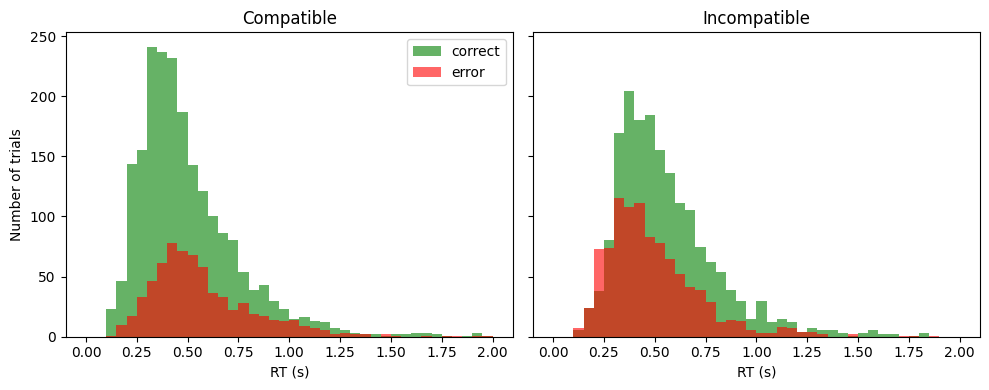

In [ ]:
bins = np.arange(0, 2.05, 0.05)

comp_correct = df_compatible[df_compatible["correct"] == 1]["rt"]
comp_error = df_compatible[df_compatible["correct"] == 0]["rt"]
incomp_correct = df_incompatible[df_incompatible["correct"] == 1]["rt"]
incomp_error = df_incompatible[df_incompatible["correct"] == 0]["rt"]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

#left: compatible trials
ax_left.hist(comp_correct, bins=bins, color="green", alpha=0.6, label="correct")
ax_left.hist(comp_error, bins=bins, color="red", alpha=0.6, label="error")
ax_left.set_title("Compatible")
ax_left.set_xlabel("RT (s)")
ax_left.set_ylabel("Number of trials")
ax_left.legend()

# right: incompatible trials
ax_right.hist(incomp_correct, bins=bins, color="green", alpha=0.6, label="correct")
ax_right.hist(incomp_error, bins=bins, color="red", alpha=0.6, label="error")
ax_right.set_title("Incompatible")
ax_right.set_xlabel("RT (s)")

plt.tight_layout()
plt.show()

##Creating DDM

In [ ]:
T_DUR = 2.5

# create model (same model fitted to each subject and condition)
def build_model():
    return pyddm.gddm(
        drift="v",
        bound='a',
        starting_position="z",
        nondecision="t0",
        noise=1,
        T_dur=T_DUR,
        parameters={"v": (-5, 5), "a": (0.1, 3), "z": (-0.9, 0.9), "t0": (0, 0.5)},
        choice_names=("correct", "error")
    )

##Fitting DDMs per subject (compatible vs incompatible)

In [ ]:
rows = []

for subject in df["subjects"].unique():
    for condition, data in [("compatible", df_compatible), ("incompatible", df_incompatible)]:
        data_subject = data[data["subjects"] == subject]

        # create sample
        sample = pyddm.Sample.from_pandas_dataframe(
            data_subject[["rt", "correct"]],
            rt_column_name="rt",
            choice_column_name="correct",
            choice_names=("correct", "error")
        )

        # create and fit the model
        model = build_model()
        model.fit(sample=sample, verbose=False)

        # store the fitted parameters
        values = model.get_model_parameters()
        rows.append({
            "subject": subject,
            "condition": condition,
            "v": float(values[0]),
            "a": float(values[1]),
            "z": float(values[2]),
            "t0": float(values[3])
        })

    print(f"subject {subject} done")

fits = pd.DataFrame(rows)
print(fits)

# mean parameter values per condition
print(fits.groupby("condition")[["v", "a", "z", "t0"]].mean())


Info: Params [1.24317048 0.48100552 0.12252262 0.1970667 ] gave -53.459811351866406
Info:pyddm:Params [1.24317048 0.48100552 0.12252262 0.1970667 ] gave -53.459811351866406
Info: Params [ 1.06560342  0.47441336 -0.12021143  0.19738703] gave -1.1706936336377467
Info:pyddm:Params [ 1.06560342  0.47441336 -0.12021143  0.19738703] gave -1.1706936336377467


subject 1 done


Info: Params [0.41370913 0.51547451 0.31978229 0.19451846] gave -4.95603277589953
Info:pyddm:Params [0.41370913 0.51547451 0.31978229 0.19451846] gave -4.95603277589953
Info: Params [ 1.30583638  0.54500002 -0.38744394  0.1939057 ] gave 27.62740209998822
Info:pyddm:Params [ 1.30583638  0.54500002 -0.38744394  0.1939057 ] gave 27.62740209998822


subject 2 done


Info: Params [0.78636149 0.63114661 0.21704692 0.24631857] gave 52.30791824652382
Info:pyddm:Params [0.78636149 0.63114661 0.21704692 0.24631857] gave 52.30791824652382
Info: Params [ 0.73358415  0.62219582 -0.2103622   0.2422265 ] gave 123.28586812233806
Info:pyddm:Params [ 0.73358415  0.62219582 -0.2103622   0.2422265 ] gave 123.28586812233806


...

subject 10 done


Info: Params [1.08903283 0.52251731 0.07872807 0.27860274] gave -1.5779672934215156
Info:pyddm:Params [1.08903283 0.52251731 0.07872807 0.27860274] gave -1.5779672934215156
Info: Params [ 1.00150119  0.52153335 -0.03671831  0.27180429] gave 24.32500919829652
Info:pyddm:Params [ 1.00150119  0.52153335 -0.03671831  0.27180429] gave 24.32500919829652


subject 11 done


Info: Params [1.02900117 0.59710224 0.31741141 0.17362068] gave -19.74639940731383
Info:pyddm:Params [1.02900117 0.59710224 0.31741141 0.17362068] gave -19.74639940731383
Info: Params [ 1.22666095  0.59312381 -0.38493414  0.17475234] gave 66.50391403865578
Info:pyddm:Params [ 1.22666095  0.59312381 -0.38493414  0.17475234] gave 66.50391403865578


subject 12 done
    subject     condition         v         a         z        t0
0         1    compatible  1.243170  0.481006  0.122523  0.197067
1         1  incompatible  1.065603  0.474413 -0.120211  0.197387
2         2    compatible  0.413709  0.515475  0.319782  0.194518
3         2  incompatible  1.305836  0.545000 -0.387444  0.193906
4         3    compatible  0.786361  0.631147  0.217047  0.246319
5         3  incompatible  0.733584  0.622196 -0.210362  0.242226
6         4    compatible  0.441132  0.666959  0.124329  0.262973
7         4  incompatible  0.474070  0.602341 -0.020044  0.263902
8         5    compatible  0.537011  0.443579  0.217514  0.115458
9         5  incompatible  0.599840  0.465950 -0.048979  0.106055
10        6    compatible  1.048712  0.585138 -0.003630  0.415305
11        6  incompatible  1.050563  0.574736  0.024866  0.423699
12        7    compatible  0.821019  0.584443  0.082029  0.218191
13        7  incompatible  0.703637  0.597457  0.066215  0.2

##Parameter comparison: compatible vs incompatible
###Paired t-tests per parameter

In [ ]:
comp = fits[fits["condition"] == "compatible"]
incomp = fits[fits["condition"] == "incompatible"]

parameters = [
    ("v", "Drift rate (v)"),
    ("a", "Boundary (a)"),
    ("z", "Starting point (z)"),
    ("t0", "Non-decision time (t0)")
]

p_values = []
for column, label in parameters:
    t, p = stats.ttest_rel(comp[column], incomp[column])
    p_values.append(p)
    print(f"{label}:")
    print(f" compatible {comp[column].mean():.3f} vs incompatible {incomp[column].mean():.3f}, t(11) = {t:.2f}, p = {p:.4f}")

Drift rate (v):
 compatible 0.761 vs incompatible 0.845, t(11) = -1.01, p = 0.3330
Boundary (a):
 compatible 0.551 vs incompatible 0.548, t(11) = 0.49, p = 0.6359
Starting point (z):
 compatible 0.157 vs incompatible -0.129, t(11) = 4.06, p = 0.0019
Non-decision time (t0):
 compatible 0.250 vs incompatible 0.249, t(11) = 0.58, p = 0.5723


###Per-subject parameters (grey = one subject, black = group mean)

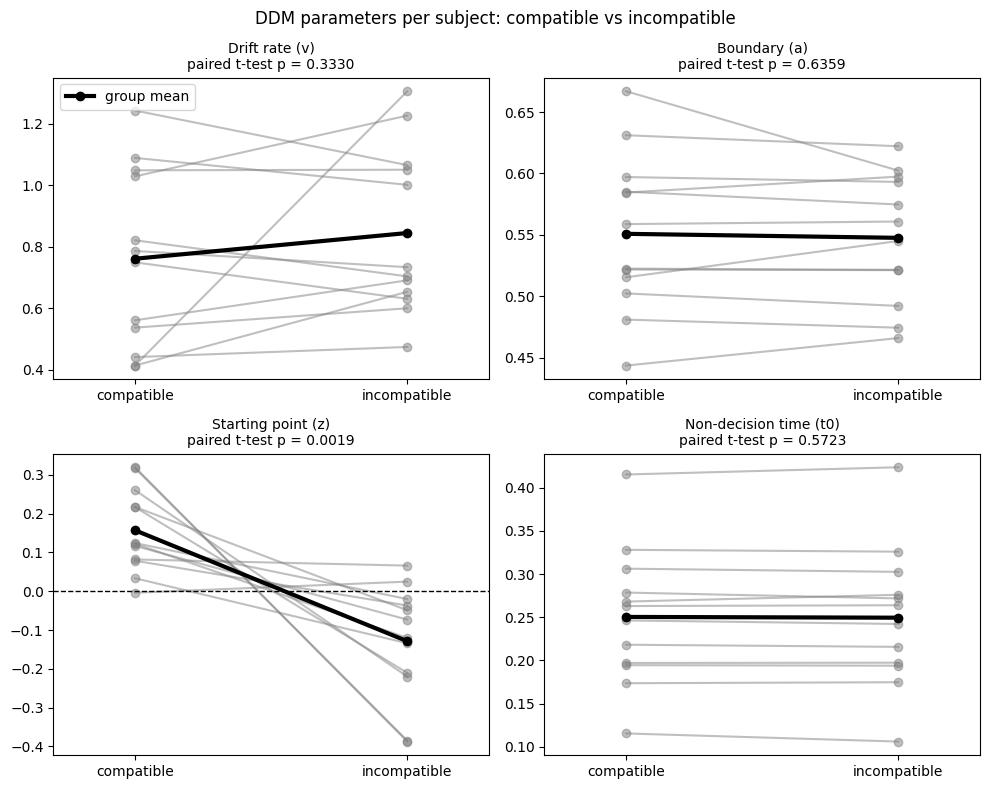

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(len(parameters)):
    column, label = parameters[i]
    ax = axes[i]

    comp_values = comp[column].values
    incomp_values = incomp[column].values

    # one grey line per subject
    for j in range(len(comp_values)):
        ax.plot([0, 1], [comp_values[j], incomp_values[j]], color="grey", alpha=0.5, marker="o")

    # group mean in black
    ax.plot([0, 1], [comp_values.mean(), incomp_values.mean()], color="black", linewidth=3, marker="o", label="group mean")

    ax.set_title(f"{label}\npaired t-test p = {p_values[i]:.4f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["compatible", "incompatible"])
    ax.set_xlim(-0.3, 1.3)

axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].legend()

fig.suptitle("DDM parameters per subject: compatible vs incompatible")
plt.tight_layout()
plt.show()

##Model fit check for one subject (data vs DDM prediction)

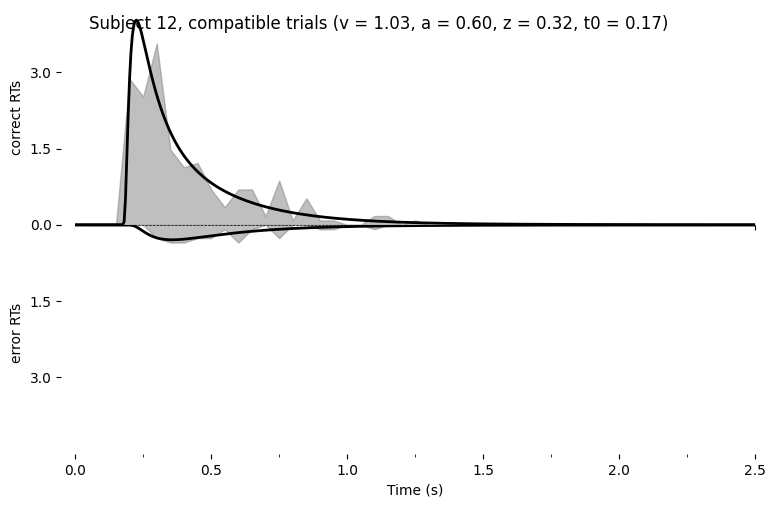

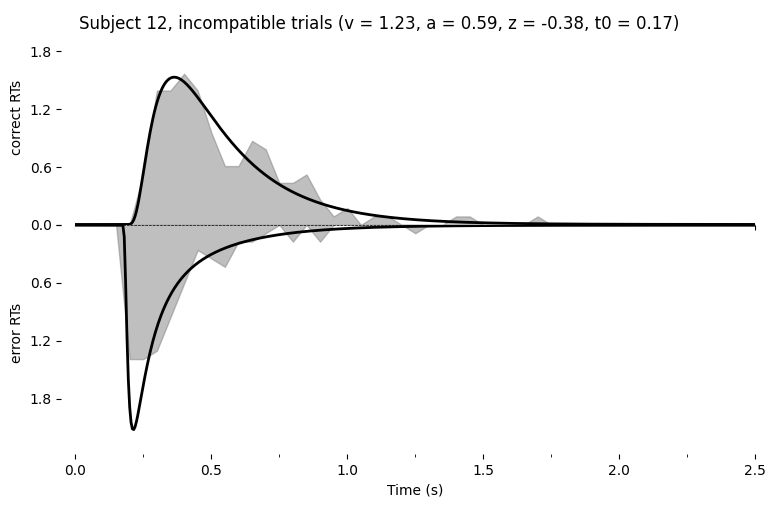

In [ ]:
SUBJECT = 12    # change this number (1- 12) to show another subject

for condition, data in [("compatible", df_compatible), ("incompatible", df_incompatible)]:
    data_subject = data[data["subjects"] == SUBJECT]

    # create sample of this subject and condition
    sample = pyddm.Sample.from_pandas_dataframe(
        data_subject[["rt", "correct"]],
        rt_column_name="rt",
        choice_column_name="correct",
        choice_names=("correct", "error")
    )

    # fitted parameters from section 5
    params = fits[(fits["subject"] == SUBJECT) & (fits["condition"] == condition)]
    v = params["v"].iloc[0]
    a = params["a"].iloc[0]
    z = params["z"].iloc[0]
    t0 = params["t0"].iloc[0]

    model = build_model()
    model.set_model_parameters([v, a, z, t0])

    fig = plt.figure(figsize=(8, 5))
    pyddm.plot.plot_fit_diagnostics(model=model, sample=sample, fig=fig, data_dt=0.05)
    fig.suptitle(f"Subject {SUBJECT}, {condition} trials (v = {v:.2f}, a = {a:.2f}, z = {z:.2f}, t0 = {t0:.2f})")
    plt.show()